In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [3]:
PATH = '../data/EMCALI/datos_procesados/'
df = pd.read_parquet(PATH + "consumo_011223_01062025.parquet", engine="pyarrow")

## Ejecución modelos

In [4]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Agrega la carpeta src al sys.path
src_path = str(Path("../src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from tqdm import tqdm
tqdm.pandas()

In [16]:
from pipe_expres.series_anomalas import get_no_validas, plot_series_no_validas

In [ ]:
primera_seleccion = get_no_validas(df, cliente_col="producto")
primera_seleccion.head()

In [ ]:
primera_seleccion.shape

In [ ]:
primera_seleccion.motivo.value_counts()

In [ ]:
df.producto.nunique()

In [ ]:
id_var = primera_seleccion[primera_seleccion.motivo=='Demasiados nulos'].sample(n=1).CLIENTE_ID.unique()[0]
id_var2 = primera_seleccion[primera_seleccion.motivo=='Serie sin varianza'].sample(n=1).CLIENTE_ID.unique()[0]


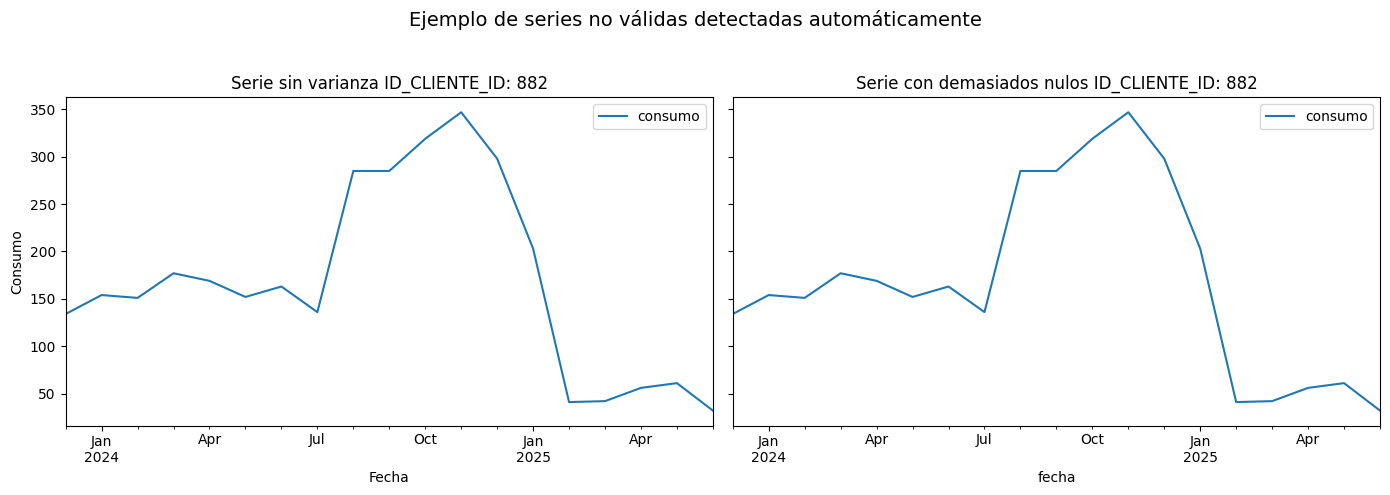

In [18]:
plot_series_no_validas(df, 882, 882, cliente_col="producto")

In [ ]:
primera_seleccion['serie_no_valida'] = 1

In [ ]:
primera_seleccion.to_csv('../data/Resultados/clientes_series_invalidas.csv', index=False)

In [ ]:
primera_seleccion = pd.read_csv('../data/Resultados/clientes_series_invalidas.csv')

### Construcción de base de recopilación final

In [ ]:
results_cliente = pd.DataFrame(df.producto.unique(), columns=['CLIENTE_ID'])

In [ ]:
df['CLIENTE_ID'] = df['producto']

In [ ]:
results_cliente = results_cliente.merge(primera_seleccion, on='CLIENTE_ID', how='left')

In [ ]:
results_cliente.shape

### Filtro de clientes

In [ ]:
from pipe_expres.limpieza import filtrar_clientes

In [ ]:
df.fecha.nunique()

In [ ]:
# Filtrar excluyendo a los no válidos identificados en 0
df_filtrado = (filtrar_clientes(df[~df.CLIENTE_ID.isin(primera_seleccion.CLIENTE_ID.unique())], umbral_consumo_min=5, percentil_alto = 0.99, 
                               eliminar_recientes=False, eliminar_altos=False, meses=19, group_cols = ['localidad', 'barrio', 'tipo_producto', 'categoria']))
df_filtrado=df_filtrado.sort_values(by=['CLIENTE_ID','fecha'], ascending=[True,True]).reset_index(drop=True)
print(df_filtrado.shape)
print('Número de clientes únicos después del filtrado:', df_filtrado.CLIENTE_ID.nunique())

In [ ]:
df_filtrado.to_parquet(PATH +"consumo_011223_01062025_filtrado.parquet", index=False)

In [11]:
df_filtrado = pd.read_parquet(PATH +"consumo_011223_01062025_filtrado.parquet", engine="pyarrow")

# Métodos Individuales

## Cambio Estructural

## 1. Cambio Estructural CUSUM Test

Usando métodos estadísticos (CUSUM). El objetivo es identificar momentos en los que el comportamiento del consumo cambia de manera significativa.

---

### 1. Preparación de Datos

- Se convierte la columna `fecha` a formato numérico ordinal para facilitar cálculos.
- Se agrupan y ordenan los datos por cliente para análisis individual.


### 2. Construcción del modelo

Detecta estadísticamente cambios estructurales mediante:

#### 2.1. Serie original:
- Ajusta una regresión lineal
- Aplica prueba CUSUM sobre residuos:
  ```python
  _, pval, _ = breaks_cusumolsresid(model.resid)

Si el valor p es menor que un umbral (alpha), se considera que hay un cambio estructural. 


Con este método se obtiene:
* Indicadores binarios de si hubo cambio estructural con/sin estacionalidad.
* Valores p del test CUSUM.
* Fechas estimadas de los cambios detectados.


### Parámetros para considerar
* alpha=0.1

In [ ]:
from pipe_expres.cusum_test import detectar_cambio_estructural_cusum

In [ ]:
resultados_3 = detectar_cambio_estructural_cusum(df_filtrado, alpha=0.1)
resultados_3.head()

In [ ]:
resultados_3.cambio_estructural.value_counts()

In [ ]:
resultados_3.sort_values(by = 'cusum_pval', ascending=True, inplace=True)
resultados_3['rank_cambio_estructural'] = np.arange(1, len(resultados_3) + 1)
resultados_3.head()

In [ ]:
resultados_3.cusum_pval.describe()

In [ ]:
resultados_3.shape

In [ ]:
resultados_3.tail()

In [ ]:
df[df.CLIENTE_ID == resultados_3.CLIENTE_ID.iloc[0]].plot(x='fecha', y='consumo', title='Consumo log del cliente con menor p-valor de cambio estructural', figsize=(12, 6));

In [ ]:
df[df.CLIENTE_ID == resultados_3.CLIENTE_ID.iloc[1]].plot(x='fecha', y='consumo', title='Consumo log del cliente con menor p-valor de cambio estructural', figsize=(12, 6));

In [ ]:
df[df.CLIENTE_ID == resultados_3.CLIENTE_ID.iloc[2]].plot(x='fecha', y='consumo', title='Consumo log del cliente con menor p-valor de cambio estructural', figsize=(12, 6));

In [ ]:
results_cliente = results_cliente.merge(resultados_3, on='CLIENTE_ID', how='outer', indicator=True)
print(results_cliente._merge.value_counts())
results_cliente.drop(columns=['_merge'], inplace=True)

In [ ]:
results_cliente.to_csv('../data/Resultados/results_cliente_cusum.csv', index=False)

In [30]:
results_cliente = pd.read_csv('../data/Resultados/results_cliente_cusum.csv')
results_cliente.head()

,CLIENTE_ID,motivo,serie_no_valida,cusum_pval,cambio_estructural,rank_cambio_estructural
0,2,NaN,NaN,NaN,NaN,NaN
1,6,NaN,NaN,NaN,NaN,NaN
2,11,NaN,NaN,NaN,NaN,NaN
3,15,NaN,NaN,NaN,NaN,NaN
4,19,NaN,NaN,NaN,NaN,NaN


## ETS - Time Series

## 2. Modelos TimeSeries LM

El proceso se basa en la comparación entre valores observados y valores predichos, usando tres enfoques distintos.

---

### Modelos utilizados

1. **ETS (Exponential Smoothing)**  
   Modelo de suavizamiento exponencial con componentes aditivos de tendencia y estacionalidad.

2. **SARIMA (Seasonal ARIMA)**  
   Modelo autoregresivo estacional con diferencias integradas y media móvil.

3. **Prophet**  
   Modelo de series temporales, diseñado para manejar estacionalidad, tendencia y días festivos.

---

### 1. Evaluación inicial con ETS
Se entrena el modelo ETS sobre 20 meses y se prueba sobre 4 meses futuros. Si el error medio absoluto (MAE) supera un umbral definido, se considera una posible anomalía.

### 2. Confirmación con SARIMA y Prophet
Solo se ejecuta para clientes con anomalía ETS.
* Se aplican ambos modelos al mismo conjunto de entrenamiento y prueba.
* Se evalúa si el MAE excede el umbral para cada uno.

### 3. Decisión por consenso
Se etiqueta una anomalía confirmada si al menos 2 de los 3 modelos (ETS, SARIMA, Prophet) la detectan.

---

### Parámetros para considerar

| Modelo     | Parámetro                  | Descripción                                              | Valor típico / Recomendación                       |
|------------|----------------------------|----------------------------------------------------------|----------------------------------------------------|
| **ETS**    | `trend`                    | Tipo de tendencia ("add", "mul", None)                   | `"add"` si hay crecimiento o descenso lineal       |
|            | `seasonal`                 | Tipo de estacionalidad                                   | `"add"` si hay estacionalidad con amplitud fija    |
|            | `seasonal_periods`         | Periodo estacional                                       | `12` si los datos son mensuales                    |
|            | `damped_trend`             | Atenúa la tendencia en el tiempo                         | `False` o `True` si la tendencia parece exagerada  |
| **SARIMA** | `order=(p,d,q)`            | Parte no estacional: AR, diferencia, MA                  | `(1,1,1)` en muchos casos                          |
|            | `seasonal_order=(P,D,Q,s)` | Parte estacional: SAR, diferencia, SMA, periodo          | `(1,1,1,12)` para estacionalidad mensual           |
|            |                            |                                                          | Ajustar usando AIC/BIC o `auto_arima` si es posible|
| **Prophet**| `yearly_seasonality`       | Activa estacionalidad anual                              | `True` para datos mensuales                        |
|            | `changepoint_prior_scale`  | Sensibilidad a cambios de tendencia                      | `0.05` por defecto, `0.1` si se quiere más flexibilidad |
|            | `seasonality_mode`         | Modo de estacionalidad ("additive" o "multiplicative")   | `"additive"` por defecto                           |
|            | `weekly_seasonality`       | Estacionalidad semanal                                   | `False` para datos mensuales                       |
|            | `daily_seasonality`        | Estacionalidad diaria                                    | `False` para datos mensuales                       |


## Comparación General de modelos

| Característica                        | ETS                         | SARIMA                      | Prophet                     |
|--------------------------------------|-----------------------------|-----------------------------|-----------------------------|
| **Estacionalidad**                   | Explícita (paramétrica)     | Estacional ARIMA            | Flexible, automática        |
| **Tendencia**                        | Lineal o suavizada          | Lineal (por diferenciación) | No lineal, con puntos de cambio |
| **Soporte para cambios estructurales** | Parcial (damped trend)      | Bueno (si bien parametrizado) | Excelente (`changepoints`) |
| **Facilidad de ajuste**              | Muy rápido, pocos parámetros| Requiere tuning cuidadoso   | Muy intuitivo, automático   |
| **Datos faltantes**                  | Poco tolerante              | Poco tolerante              | Tolerante                   |
| **Visualización**                    | Manual                      | Manual                      | Automática, con componentes |
| **Interpretabilidad**                | Alta                        | Media                       | Alta                        |
| **Uso recomendado**                  | Series estables, bien comportadas | Series con estacionalidad clara | Series con tendencia cambiante o eventos externos |



In [9]:
from pipe_expres.time_series_ml import evaluar_anomalia_ets, confirmar_anomalia_completa, consenso

Importing plotly failed. Interactive plots will not work.


In [20]:
df_filtrado.CLIENTE_ID.nunique()

596275

In [30]:
resultados_ets = [evaluar_anomalia_ets(df_filtrado, cid, train_len=15, test_len=4, umbral_mae=0.9) for cid in tqdm(df_filtrado.CLIENTE_ID.unique()[550000:], desc="Evaluando anomalías ETS")]
resultados_ets = pd.DataFrame(resultados_ets)
resultados_ets.to_csv('../data/Resultados/resultados_ets550000_.csv', index=False)

Evaluando anomalías ETS: 100%|██████████| 46275/46275 [22:06<00:00, 34.90it/s]


In [16]:
anom_ets = resultados_ets[resultados_ets['anomalia_ets'] == True].copy()

In [23]:
anom_ets

,CLIENTE_ID,mae_ets,anomalia_ets,suficientes_datos,motivo
27,337038,59.179064,True,True,
29,337081,150.602663,True,True,
57,337261,69.119046,True,True,
94,337588,610.541141,True,True,
242,338994,37.784451,True,True,
...,...,...,...,...,...
49446,661404,168.119644,True,True,
49558,662013,161.401082,True,True,
49649,662583,188.483322,True,True,
49706,662901,125.015320,True,True,


In [ ]:
resultados_ets.to_csv('../data/Resultados/resultados_ets.csv', index=False)

In [ ]:
resultados_ets = pd.read_csv('../data/Resultados/resultados_ets.csv')

In [5]:
from pathlib import Path

results_dir = Path("../data/Resultados")
archivos_ets = sorted(results_dir.glob("resultados_ets*.csv"))

print(f"Archivos encontrados: {[f.name for f in archivos_ets]}")

resultados_ets = pd.concat(
    (pd.read_csv(f) for f in archivos_ets),
    ignore_index=True,
    copy=False,
)

print("Concatenación completada:", resultados_ets.shape)

Archivos encontrados: ['resultados_ets0_50000.csv', 'resultados_ets100000_150000.csv', 'resultados_ets150000_200000.csv', 'resultados_ets200000_250000.csv', 'resultados_ets250000_350000.csv', 'resultados_ets350000_450000.csv', 'resultados_ets450000_550000.csv', 'resultados_ets50000_100000.csv', 'resultados_ets550000_.csv']
Concatenación completada: (596275, 5)


In [6]:
anom_ets = resultados_ets[resultados_ets['anomalia_ets'] == True].copy()

In [7]:
anom_ets.shape

(13618, 5)

In [20]:
# Confirmación Prophet + AutoArima solo en anómalos
ids_a_confirmar = anom_ets["CLIENTE_ID"].values[:4000]
resultados_confirma = []

for cid in tqdm(ids_a_confirmar):
    res = confirmar_anomalia_completa(df_filtrado, cid, train_len=15, test_len=4)
    res["CLIENTE_ID"] = cid
    resultados_confirma.append(res)

df_confirma = pd.DataFrame(resultados_confirma)
df_out_final = anom_ets.merge(df_confirma, on="CLIENTE_ID", how="left")

# Crea una columna de anomalía final (por consenso de al menos 2 modelos)

df_out_final["anomalia_final"] = df_out_final.apply(consenso, axis=1)

  0%|          | 0/4000 [00:00<?, ?it/s]10:26:10 - cmdstanpy - INFO - Chain [1] start processing
10:26:11 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 1/4000 [00:00<40:07,  1.66it/s]10:26:11 - cmdstanpy - INFO - Chain [1] start processing
10:26:12 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 2/4000 [00:01<58:34,  1.14it/s]10:26:12 - cmdstanpy - INFO - Chain [1] start processing
10:26:13 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 3/4000 [00:02<1:07:02,  1.01s/it]10:26:13 - cmdstanpy - INFO - Chain [1] start processing
10:26:14 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 4/4000 [00:03<1:05:40,  1.01it/s]10:26:14 - cmdstanpy - INFO - Chain [1] start processing
10:26:16 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 5/4000 [00:06<1:35:12,  1.43s/it]10:26:16 - cmdstanpy - INFO - Chain [1] start processing
10:26:17 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 6/4000 [00:07<1:32:

In [21]:
df_out_final.to_csv('../data/Resultados/anomalias_confirmadas_ets1.csv', index=False)

In [25]:
# Confirmación Prophet + AutoArima solo en anómalos
ids_a_confirmar = anom_ets["CLIENTE_ID"].values[12000:]
resultados_confirma = []

for cid in tqdm(ids_a_confirmar):
    res = confirmar_anomalia_completa(df_filtrado, cid, train_len=15, test_len=4)
    res["CLIENTE_ID"] = cid
    resultados_confirma.append(res)

df_confirma = pd.DataFrame(resultados_confirma)
df_out_final = anom_ets.merge(df_confirma, on="CLIENTE_ID", how="left")

# Crea una columna de anomalía final (por consenso de al menos 2 modelos)

df_out_final["anomalia_final"] = df_out_final.apply(consenso, axis=1)
df_out_final.to_csv('../data/Resultados/anomalias_confirmadas_ets4.csv', index=False)

  0%|          | 0/1618 [00:00<?, ?it/s]13:15:57 - cmdstanpy - INFO - Chain [1] start processing
13:16:05 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 1/1618 [00:08<3:42:04,  8.24s/it]13:16:05 - cmdstanpy - INFO - Chain [1] start processing
13:16:07 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 2/1618 [00:09<1:54:02,  4.23s/it]13:16:07 - cmdstanpy - INFO - Chain [1] start processing
13:16:07 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 3/1618 [00:09<1:05:56,  2.45s/it]13:16:07 - cmdstanpy - INFO - Chain [1] start processing
13:16:15 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 4/1618 [00:18<2:05:28,  4.66s/it]13:16:15 - cmdstanpy - INFO - Chain [1] start processing
13:16:23 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 5/1618 [00:25<2:36:38,  5.83s/it]13:16:23 - cmdstanpy - INFO - Chain [1] start processing
13:16:24 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 6/1618 [00:26<1

In [26]:
from pathlib import Path

results_dir = Path("../data/Resultados")
archivos_confirmadas = sorted(results_dir.glob("anomalias_confirmadas_ets*.csv"))
print(f"Archivos encontrados: {[f.name for f in archivos_confirmadas]}")

df_out_final = pd.concat(
    (pd.read_csv(f) for f in archivos_confirmadas),
    ignore_index=True,
)

# Eliminar duplicados por CLIENTE_ID si los hubiera
df_out_final = df_out_final.drop_duplicates(subset="CLIENTE_ID").reset_index(drop=True)

print(f"Shape final: {df_out_final.shape}")
df_out_final.head()

Archivos encontrados: ['anomalias_confirmadas_ets1.csv', 'anomalias_confirmadas_ets2.csv', 'anomalias_confirmadas_ets3.csv', 'anomalias_confirmadas_ets4.csv']
Shape final: (13618, 11)


,CLIENTE_ID,mae_ets,anomalia_ets,suficientes_datos,motivo,mae_arima,anomalia_arima,error_arima,mae_prophet,anomalia_prophet,anomalia_final
0,882,360.803989,True,True,NaN,NaN,NaN,zero-size array to reduction operation maximum...,235.794590,True,True
1,1042,160.084698,True,True,NaN,NaN,NaN,zero-size array to reduction operation maximum...,65.383185,False,False
2,1503,117.224019,True,True,NaN,NaN,NaN,zero-size array to reduction operation maximum...,30.995858,False,False
3,1563,315.210974,True,True,NaN,NaN,NaN,zero-size array to reduction operation maximum...,75.373880,False,False
4,2117,111.858854,True,True,NaN,NaN,NaN,zero-size array to reduction operation maximum...,190.891973,True,True


In [ ]:
df_out_final

In [28]:
df_out_final.sort_values(by=['mae_ets', 'mae_arima', 'mae_prophet'], ascending=[False, False, False], inplace=True)

In [29]:
df_out_final['rank_ts'] = np.arange(1, len(df_out_final) + 1)

In [32]:
results_cliente = results_cliente.merge(df_out_final[['CLIENTE_ID', 'mae_ets', 'mae_arima', 'mae_prophet', 'rank_ts']], on='CLIENTE_ID', how='outer', indicator=True)
print(results_cliente._merge.value_counts())
results_cliente.drop(columns=['_merge'], inplace=True)

_merge
left_only     1016150
both            13618
right_only          0
Name: count, dtype: int64


In [33]:
results_cliente.to_csv('../data/Resultados/results_cliente_metodos_individuales.csv', index=False)

# Métodologías de Grupo

# Distribuciones Gaussianas
Este método compara el consumo actual con el del mismo mes del año anterior. 
* Se basa en la suposición de que **los datos siguen una distribución normal multivariada.**

---

### 1. Preparación de los Datos

- Se filtran los datos para considerar solo los últimos 24 meses.
- Se eliminan clientes con:
  - Consumo cero en algún mes.
  - Medidor recién instalado.
  - Consumos consistentemente extremos (percentil > 95). **SEPARAR POR USO DE SUELO**
- Se crea la columna `consumo_prev_year` aplicando un `shift(12)` por cliente.


### 2. Construcción del Espacio de Características

Se define un espacio bidimensional:

- `consumo_prev_year`: consumo hace 12 meses.
- `consumo_actual`: consumo en el mes actual.

Cada cliente es un punto en este espacio.


### 3. Cálculo de la Matriz de Varianza-Covarianza

Se calcula la **matriz de varianza-covarianza** para este grupo de datos:

```python
mu = X.mean(axis=0)
cov_matrix = np.cov(X, rowvar=False, ddof=0)
```

**Propiedades importantes:**
Representa cómo varían conjuntamente las dos variables (consumo actual y pasado).

Es una matriz 2×2 simétrica:

* Diagonal: varianzas individuales.

* Fuera de la diagonal: covarianza.

Si el determinante es cero (singularidad), se añade un valor a la diagonal:

```python
if np.linalg.det(cov_matrix) == 0:
    cov_matrix += np.eye(2) * 1e-6
```


### 4. Distancia de Mahalanobis
Se calcula para cada cliente la distancia respecto al centroide multivariado:

```python
inv_cov = np.linalg.inv(cov_matrix)
diffs = X - mu
mahalanobis_sq = (diffs @ inv_cov * diffs).sum(axis=1)
mahalanobis_dist = np.sqrt(mahalanobis_sq)
```

### 5. Detección de Anomalías
Se considera un umbral (por ejemplo, 2 desviaciones estándar) para identificar puntos anómalos:

---
### Párametros para considerar:
* Tamaño mínimo de los grupos
* Desviaciones estándar para ser anómalo

In [ ]:
from pipe_expres.features import crear_features, feature_consumo_log,feature_consumo_prev_year,feature_year_month
from pipe_expres.gaussiana_method import calcular_fraud_scores,plot_consumo_grupo
from pipe_expres.features_based import extract_consumption_features, detectar_outliers_por_grupo

In [ ]:
feature_funcs = [
    feature_consumo_log,
    feature_consumo_prev_year,
    feature_year_month,
]

# Crea las features
df_features = crear_features(df_filtrado, feature_funcs)

In [ ]:
df_features

In [ ]:
group_cols = ['localidad', 'barrio', 'tipo_producto', 'categoria', 'year_month'] ## se puede ajustar para la variable de ID de transformador

In [ ]:
df_features['year_month'] = df_features['fecha'].dt.to_period('M').astype(str)
resultados_1 = calcular_fraud_scores(df_features, show_progress=True,variables_consumo=["consumo_log_prev_year", "consumo_log"], 
                                     min_group_size=25, group_cols=group_cols)
print(resultados_1.shape)

In [ ]:
resultados_1['year_month'] = pd.to_datetime(resultados_1['year_month'], format='%Y-%m')
resultados_1 = resultados_1.sort_values(by='year_month', ascending=False)

# Agrupa por cliente y toma el primero (el más reciente)
resultados_df_last = resultados_1.groupby('CLIENTE_ID', as_index=False).first()
resultados_df_last.sort_values(by='fraud_score', ascending=False, inplace=True)

# Ordena por score de anomalia y asigna un ranking
resultados_df_last['rank_gaussian'] = np.linspace(1, len(resultados_df_last), len(resultados_df_last))

In [ ]:
results_cliente = results_cliente.merge(resultados_1, on='CLIENTE_ID', how='outer', indicator=True)
print(results_cliente._merge.value_counts())
results_cliente.drop(columns=['_merge'], inplace=True)

In [ ]:
df[df.CLIENTE_ID==256898].plot(x='fecha', y='consumo', title='Consumo log del cliente con mayor score de anomalía', figsize=(12, 6));

In [ ]:
#['localidad', 'barrio', 'tipo_producto', 'categoria', 'year_month']
# Gráfico del grupo donde se encuentra el cliente con mayor score de anomalia
pos = 0
plot_consumo_grupo(
    resultados_1,
    localidad=df[df.CLIENTE_ID == resultados_df_last.CLIENTE_ID.iloc[pos]].localidad.unique()[0],
    barrio=df[df.CLIENTE_ID == resultados_df_last.CLIENTE_ID.iloc[pos]].barrio.unique()[0],
    tipo_producto=df[df.CLIENTE_ID == resultados_df_last.CLIENTE_ID.iloc[pos]].tipo_producto.unique()[0],
    categoria=df[df.CLIENTE_ID == resultados_df_last.CLIENTE_ID.iloc[pos]].categoria.unique()[0],
    year_month=resultados_1.year_month.iloc[pos],
    min_obs=1,
    n_std=2,
    id_interes=resultados_df_last.CLIENTE_ID.iloc[pos]
)

In [ ]:
df_full, df_features = extract_consumption_features(df_filtrado, n_jobs=8, group_vars=['barrio', 'tipo_producto', 'categoria'])

In [ ]:

df[~df.CLIENTE_ID.isin(df_filtrado.CLIENTE_ID.unique() )][['producto', 'localidad']].drop_duplicates().to_csv('../../data/EMCALI/Resultados_preliminares/clientes_excluidos_filtro.csv', index=False)

## 2. Isolation Forest

Extrae estadísticas de las series de consumo sobre su comportamiento temporal. Luego, aplica técnicas de aprendizaje automático para identificar posibles anomalías.

---

### 1. Filtrado de Datos

- Se asegura que el campo de fecha esté en formato ordinal para orden temporal.
- Se rellenan valores nulos de consumo con 0 para evitar errores en el análisis. **DISCUTIR** (Mejor interpolar)

### 2. Extracción de Características Temporales con `tsfresh`

Se extraen features estadísticas automáticas de series temporales por cliente.

* number_peaks
* sample_entropy
* skewness, kurtosis
* autocorrelation
* fft_coefficient, linear_trend, entre otros.

### 3. Uso de metadata, de cada cliente para el entrenamiento del modelo
Por cada grupo (barrio, estrato, clase de servicio), se entrena un modelo para detectar comportamientos atípicos.

Se usa StandardScaler para estandarizar las variables numéricas. Se entrena IsolationForest.

---
### Parámetros para considerar:
* Contaminación
* Tamaño mínimo de los grupos
* Características extraídas de `tsfresh`

In [ ]:
resultados_2 = detectar_outliers_por_grupo(
    df=df_full,
    feature_cols=df_features,            # lista de columnas numéricas
    min_group_size=25,
    contamination=0.05,
    return_only_anomalies=False,
)

In [ ]:
resultados_2.sort_values(by='anomaly_score', ascending=False, inplace=True)

In [ ]:
results_cliente = results_cliente.merge(resultados_2, on='CLIENTE_ID', how='outer', indicator=True)
print(results_cliente._merge.value_counts())
results_cliente.drop(columns=['_merge'], inplace=True)

In [ ]:
df_filtrado[df_filtrado.CLIENTE_ID == resultados_2.CLIENTE_ID.iloc[0]].sort_values(by='fecha', ascending=True).set_index('fecha').consumo.plot(
    title=f"Consumo del cliente {resultados_2.CLIENTE_ID.iloc[0]} con mayor score de anomalia",
    figsize=(12, 6),
    ylabel='Consumo',
    xlabel='Fecha',
    legend=True
);

In [ ]:
## FULL COMPILADO DE RESULTADOS DE APRENDIZAJE NO SUPERVISADO
results_cliente.to_csv('../data/Resultados/resultados_completos_clientes.csv', index=False)